In [19]:
import duckdb
import numpy as np
import pandas as pd
import igraph as ig

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
con = duckdb.connect()


In [20]:
graph_end_date = "2024-08-31"
block_window_start = "2024-09-01"
block_window_end = "2024-09-30"

behavior_window_len = 30
min_blocks_prior = 3
TOXIC_THRESHOLD = 5   


In [21]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE active_users AS
SELECT did_id
FROM read_parquet('blocks.parquet')
WHERE created_date BETWEEN DATE '{block_window_start}' - INTERVAL 1 MONTH
                       AND DATE '{block_window_start}' - INTERVAL 1 DAY
GROUP BY did_id
HAVING COUNT(*) >= {min_blocks_prior}
""")

print("Active users:",
      con.execute("SELECT COUNT(*) FROM active_users").fetchone()[0])


Active users: 36343


In [22]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE edges AS
SELECT DISTINCT
    p.did_id AS src,
    p.reply_parent_did_id AS dst
FROM read_parquet('posts.parquet') p
JOIN active_users a1 ON p.did_id = a1.did_id
JOIN active_users a2 ON p.reply_parent_did_id = a2.did_id
WHERE p.reply_parent_did_id IS NOT NULL
  AND p.created_date <= DATE '{graph_end_date}'
""")

edges = con.execute("SELECT src, dst FROM edges").fetchdf()

g = ig.Graph.TupleList(
    edges.itertuples(index=False),
    directed=True
)

g.simplify(multiple=True, loops=True)
print(g.summary())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

IGRAPH DN-- 31273 2678790 -- 
+ attr: name (v)


In [23]:
g_und = g.as_undirected(combine_edges="first")

communities = g_und.community_leiden(
    objective_function="modularity",
    resolution=1.0
)

g.vs["community"] = communities.membership
print("Number of communities:", len(set(communities.membership)))


Number of communities: 1855


In [24]:
g.vs["out_degree"] = g.outdegree()
g.vs["in_degree"] = g.indegree()
g.vs["pagerank"] = g.pagerank()
g.vs["core"] = g.coreness()
g.vs["clustering"] = g_und.transitivity_local_undirected(mode="zero")


In [25]:
df = pd.DataFrame({
    "did_id": g.vs["name"],
    "community": g.vs["community"],
    "out_degree": g.vs["out_degree"],
    "in_degree": g.vs["in_degree"],
    "pagerank": g.vs["pagerank"],
    "core": g.vs["core"],
    "clustering": g.vs["clustering"]
})


In [26]:
behavior_start = pd.to_datetime(graph_end_date) - pd.Timedelta(days=behavior_window_len - 1)

behavior_df = con.execute(f"""
SELECT
    did_id,
    COUNT(*) AS post_count,
    COUNT(reply_parent_did_id) AS reply_count
FROM read_parquet('posts.parquet')
WHERE created_date BETWEEN DATE '{behavior_start.date()}'
                        AND DATE '{graph_end_date}'
GROUP BY did_id
""").fetchdf()

df = df.merge(behavior_df, on="did_id", how="left").fillna(0)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [27]:
label_df = con.execute(f"""
SELECT
    subject_did_id AS did_id,
    COUNT(*) AS future_blocks
FROM read_parquet('blocks.parquet')
WHERE created_date BETWEEN DATE '{block_window_start}'
                      AND DATE '{block_window_end}'
GROUP BY subject_did_id
""").fetchdf()

df = df.merge(label_df, on="did_id", how="left").fillna(0)

df["toxic"] = (df["future_blocks"] > TOXIC_THRESHOLD).astype(int)
df["toxic"].value_counts(normalize=True)


toxic
0    0.808013
1    0.191987
Name: proportion, dtype: float64

In [28]:
community_stats = (
    df.groupby("community")
      .agg(
          community_size=("did_id", "count"),
          community_block_rate=("toxic", "mean"),
          avg_future_blocks=("future_blocks", "mean")
      )
      .reset_index()
)

df = df.merge(community_stats, on="community", how="left")


In [29]:
df["reply_ratio"] = df["reply_count"] / (df["post_count"] + 1)
df["posts_per_day"] = df["post_count"] / behavior_window_len
df["in_out_ratio"] = df["in_degree"] / (df["out_degree"] + 1)

df["rel_out_degree"] = (
    df["out_degree"] /
    (df.groupby("community")["out_degree"].transform("mean") + 1e-3)
)

log_features = [
    "out_degree", "in_degree",
    "post_count", "reply_count",
    "posts_per_day"
]

for col in log_features:
    df[col] = np.log1p(df[col])


In [ ]:
FEATURES = [
    # Individual graph
    "out_degree", "in_degree", "pagerank",
    "core", "clustering", "in_out_ratio",

    # Behavior
    "posts_per_day", "reply_ratio",

    # Community context
    "community_size",
    "community_block_rate",
    "avg_future_blocks",
    "rel_out_degree"
]


In [31]:
X = df[FEATURES]
y = df["toxic"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=12,
    min_samples_leaf=30,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)


In [32]:
print(classification_report(y_val, y_pred))


              precision    recall  f1-score   support

           0       0.92      0.82      0.87      5054
           1       0.48      0.70      0.57      1201

    accuracy                           0.80      6255
   macro avg       0.70      0.76      0.72      6255
weighted avg       0.84      0.80      0.81      6255



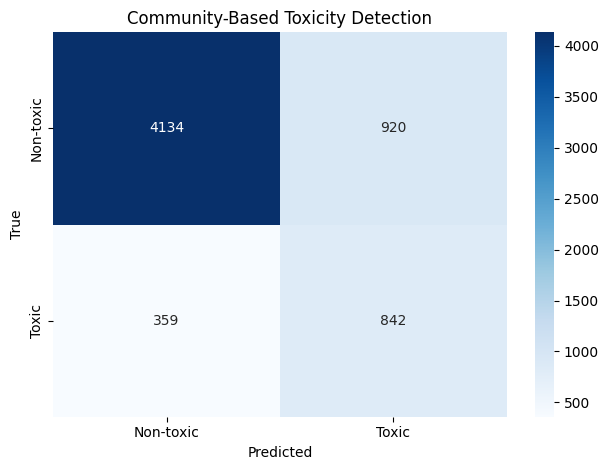

In [33]:
cm = confusion_matrix(y_val, y_pred)

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Non-toxic", "Toxic"],
    yticklabels=["Non-toxic", "Toxic"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Community-Based Toxicity Detection")
plt.tight_layout()
plt.show()


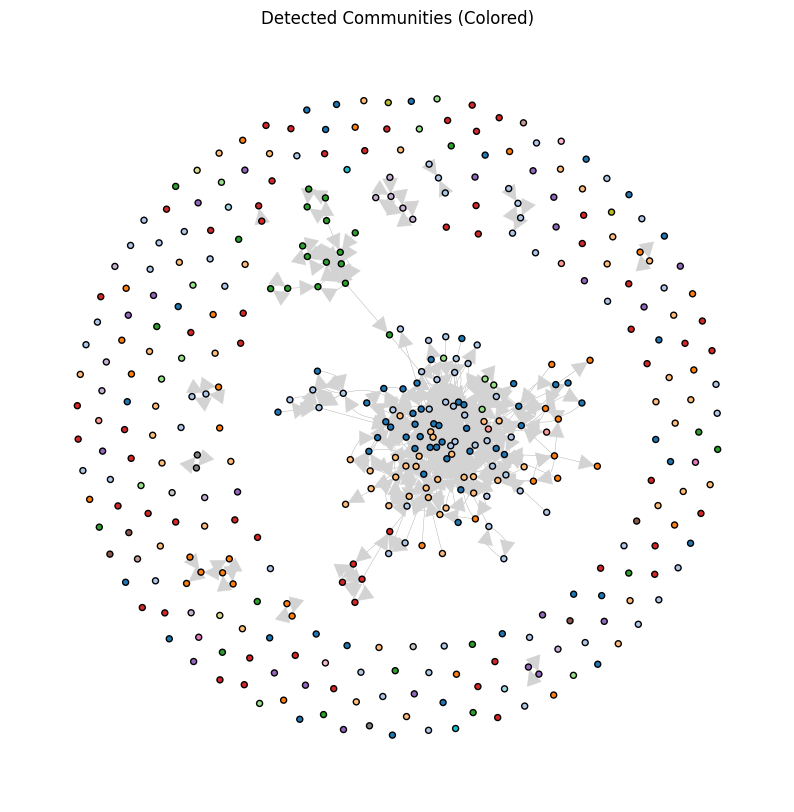

In [ ]:
# Sample nodes for visualization
np.random.seed(42)
sample_nodes = np.random.choice(g.vs.indices, size=400, replace=False)
sub_g = g.subgraph(sample_nodes)

# Community labels
communities_sub = [v["community"] for v in sub_g.vs]
unique_comms = sorted(set(communities_sub))

# Generate color palette as *tuples*, not numpy arrays
palette = [
    tuple(plt.cm.tab20(i % 20))
    for i in range(len(unique_comms))
]

comm_to_color = dict(zip(unique_comms, palette))

sub_g.vs["color"] = [comm_to_color[c] for c in communities_sub]

# Layout
layout = sub_g.layout("fr")

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
ig.plot(
    sub_g,
    target=ax,
    layout=layout,
    vertex_size=6,
    vertex_color=sub_g.vs["color"],
    edge_width=0.3,
    edge_color="lightgray"
)

plt.title("Detected Communities (Colored)")
plt.show()


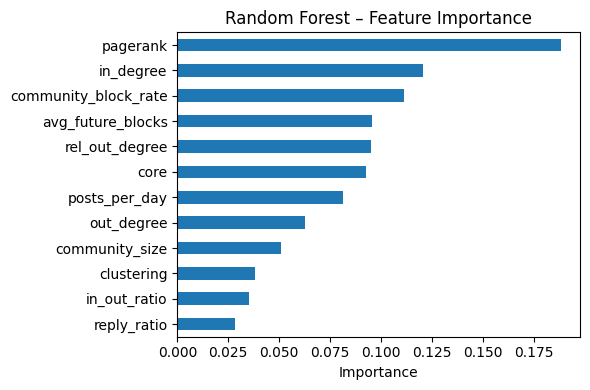

In [41]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=FEATURES
).sort_values()

plt.figure(figsize=(6,4))
rf_importance.plot(kind="barh")
plt.title("Random Forest – Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()